In [ ]:
from prophet import Prophet

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================================
# LOAD DATA
# =========================================
df_train = pd.read_csv(
    "https://raw.githubusercontent.com/sarthaksoni25/Rossmann-Store-Sales-Prediction/master/dataset/train.csv",
    low_memory=False
)

df_store = pd.read_csv(
    "https://raw.githubusercontent.com/sarthaksoni25/Rossmann-Store-Sales-Prediction/master/dataset/store.csv",
    low_memory=False
)

df = df_train.merge(df_store, on="Store", how="left")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Store", "Date"])
df = df[df["Open"] == 1].copy()

# =========================================
# FEATURE ENGINEERING
# =========================================
def fe(df):
    df = df.copy()
    df["DayOfWeek"] = df["Date"].dt.dayofweek
    df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

    df["StateHoliday"] = df["StateHoliday"].astype(str).map(
        {"0":0, "a":1, "b":1, "c":1}
    ).fillna(0)

    df["SchoolHoliday"] = df["SchoolHoliday"].fillna(0)

    df["StoreType"] = df["StoreType"].astype("category").cat.codes
    df["Assortment"] = df["Assortment"].astype("category").cat.codes

    df["CompetitionDistance"] = df["CompetitionDistance"].fillna(
        df["CompetitionDistance"].median()
    )

    df["Promo2"] = df["Promo2"].fillna(0)

    return df

df = fe(df)

# =========================================
# SELECT STORE
# =========================================
store_id = 733
store_df = df[df["Store"] == store_id].copy()
store_df.set_index("Date", inplace=True)

full_index = pd.date_range(store_df.index.min(), store_df.index.max(), freq="D")
store_df = store_df.reindex(full_index)

store_df["Sales"] = store_df["Sales"].fillna(0)

for col in ["Promo","SchoolHoliday","StateHoliday",
            "StoreType","Assortment","CompetitionDistance","Promo2"]:
    store_df[col] = store_df[col].ffill()

# =========================================
# FEATURES
# =========================================
store_df["DayOfWeek"] = store_df.index.dayofweek
store_df["IsWeekend"] = (store_df["DayOfWeek"] >= 5).astype(int)

store_df["lag_1"] = store_df["Sales"].shift(1)
store_df["lag_7"] = store_df["Sales"].shift(7)
store_df["lag_14"] = store_df["Sales"].shift(14)

store_df = store_df.fillna(0)

# =========================================
# SPLIT
# =========================================
split = int(len(store_df) * 0.8)

train = store_df.iloc[:split]
test = store_df.iloc[split:]

y_train = train["Sales"]
y_test = test["Sales"]

exog_cols = ["Promo","SchoolHoliday","IsWeekend","lag_1","lag_7","lag_14"]

X_train = train[exog_cols]
X_test = test[exog_cols]

# =========================================
# STATIONARITY CHECK
# =========================================
def check_stationarity(series, alpha=0.05):
    result = adfuller(series.dropna())
    p_value = result[1]

    print("\nADF Statistic:", result[0])
    print("p-value:", p_value)

    return p_value < alpha

def make_stationary(series, max_diff=2):
    d = 0
    temp = series.copy()

    while d <= max_diff:
        print(f"\nChecking stationarity at d = {d}")
        if check_stationarity(temp):
            print("Series is STATIONARY ✅")
            return d
        else:
            print("NON-STATIONARY → differencing...")
            temp = temp.diff().dropna()
            d += 1

    print("Max differencing reached.")
    return d


# Apply stationarity check
d_used = make_stationary(y_train)
print(f"\nFinal differencing order: d = {d_used}")


# =========================================
# METRICS
# =========================================
def evaluate(y_true, y_pred, k):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred)/(y_true+1e-8))) * 100
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    adj_r2 = 1 - (1-r2)*(n-1)/(n-k-1)
    return rmse, mae, mape, r2, adj_r2

# =========================================
# MODEL RUNNER
# =========================================
results_list = []
models_dict = {}

def run_model(name, model, y_train, y_test, exog_train=None, exog_test=None):

    fitted = model.fit()

    if exog_test is not None:
        preds = fitted.predict(
            start=len(y_train),
            end=len(y_train)+len(y_test)-1,
            exog=exog_test
        )
    else:
        preds = fitted.predict(
            start=len(y_train),
            end=len(y_train)+len(y_test)-1
        )

    preds = pd.Series(preds, index=y_test.index)

    rmse, mae, mape, r2, adj_r2 = evaluate(y_test, preds, len(fitted.params))
    aic = fitted.aic if hasattr(fitted, "aic") else None

    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("MAPE:", mape)
    print("R2:", r2)
    print("AIC:", aic)

    results_list.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2,
        "Adj_R2": adj_r2,
        "AIC": aic
    })

    models_dict[name] = fitted

    plt.figure(figsize=(12,5))
    plt.plot(y_test, label="Actual")
    plt.plot(preds, label="Predicted")
    plt.title(name)
    plt.legend()
    plt.grid()
    plt.show()


Checking stationarity at d = 0

ADF Statistic: -4.285131901144772
p-value: 0.0004712972731015843
Series is STATIONARY ✅

Final differencing order: d = 0


/tmp/ipykernel_10082/462672151.py:88: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  store_df = store_df.fillna(0)


In [ ]:
# =========================================
# RUN MODELS
# =========================================


AR
RMSE: 1744.8520119211214
MAE: 1385.4920402935138
MAPE: 8.800980190379578
R2: -0.07586644030458922
AIC: 12594.522568041808


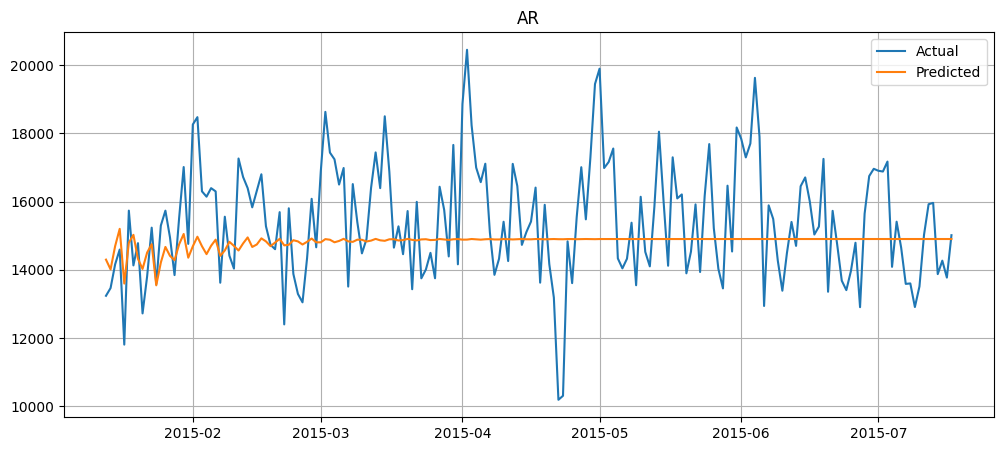

In [ ]:
run_model("AR", AutoReg(y_train, lags=14), y_train, y_test)


MA
RMSE: 1768.7408365588867
MAE: 1398.1853750452124
MAPE: 8.876450366676108
R2: -0.10552754900592864
AIC: 12874.364695493492


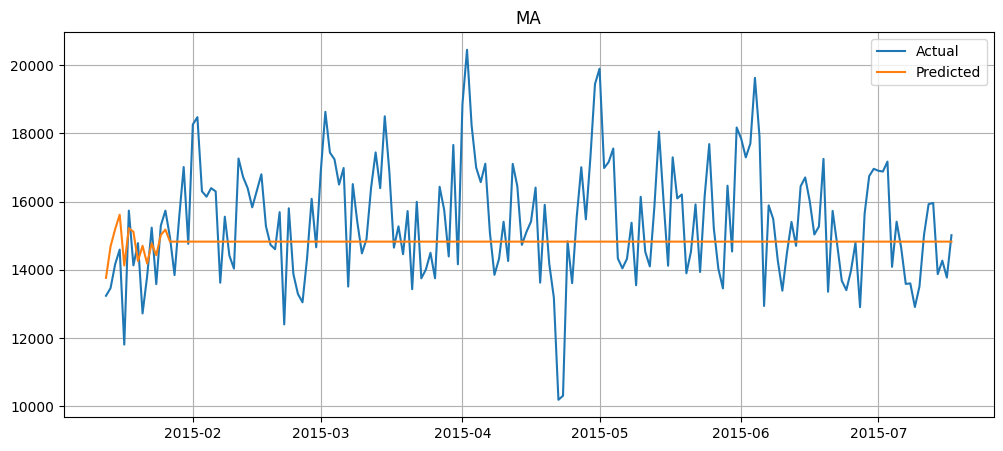

In [ ]:
run_model("MA", ARIMA(y_train, order=(0,0,14)), y_train, y_test)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



ARMA
RMSE: 1697.475640532929
MAE: 1307.220527795757
MAPE: 8.264805389902746
R2: -0.018235571905231618
AIC: 12769.984959812853


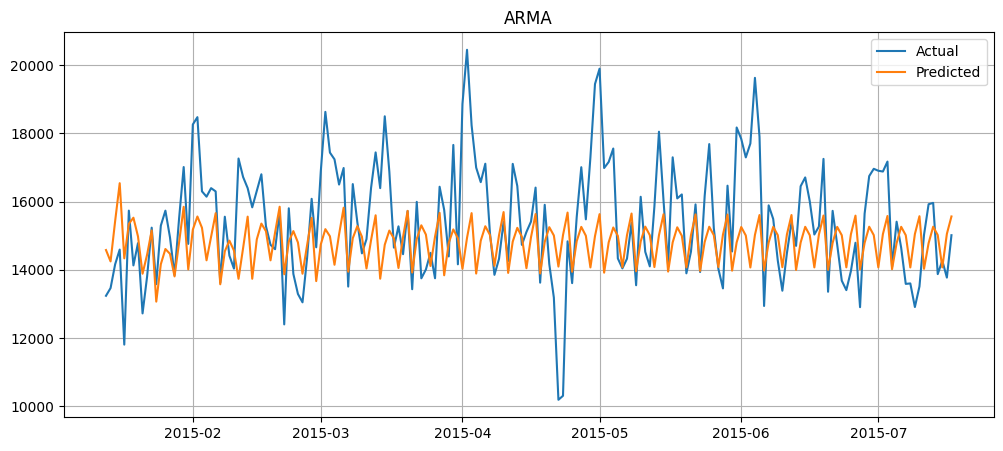

In [ ]:
run_model("ARMA", ARIMA(y_train, order=(7,0,14)), y_train, y_test)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



ARIMA
RMSE: 1645.9907199928628
MAE: 1270.1371576877484
MAPE: 8.098032660179241
R2: 0.042594477389702234
AIC: 12766.959988354862


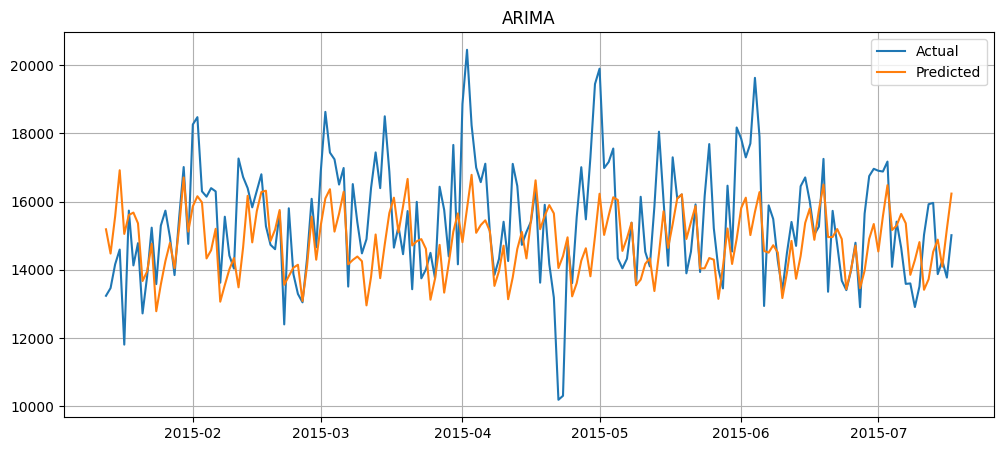

In [ ]:
run_model("ARIMA", ARIMA(y_train, order=(7,d_used,7)), y_train, y_test)


SARIMA
RMSE: 1556.9189433577444
MAE: 1170.942362494435
MAPE: 7.558796314710914
R2: 0.1434096662948513
AIC: 12700.956253337063


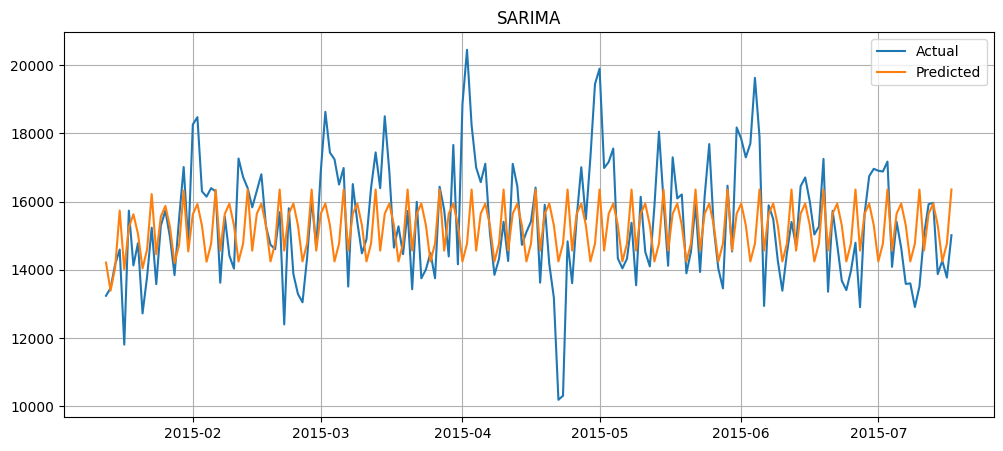

In [ ]:
run_model("SARIMA",
          SARIMAX(y_train, order=(1,d_used,1), seasonal_order=(1,1,1,7)),
          y_train, y_test)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



ARIMAX
RMSE: 1511.8149972542174
MAE: 1196.0307442901658
MAPE: 7.595383448751712
R2: 0.1923216120652742
AIC: 12905.45431921347


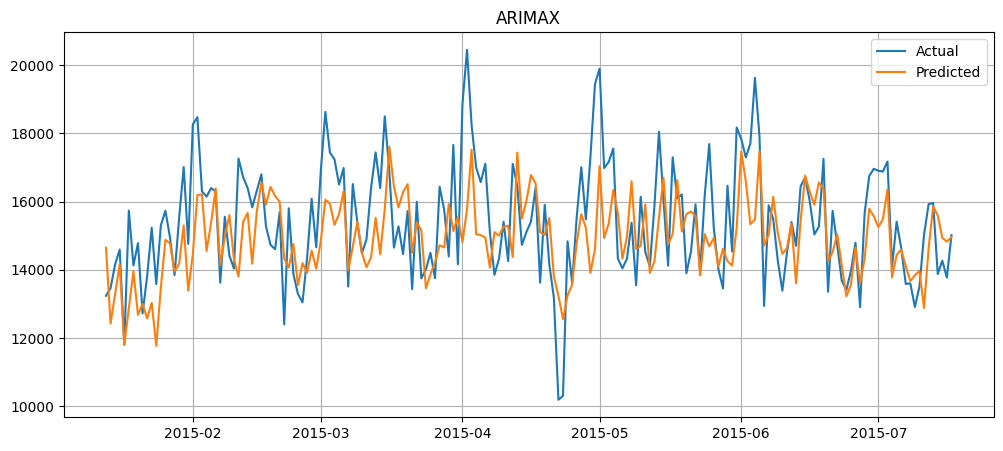

In [ ]:
run_model("ARIMAX",
          SARIMAX(y_train, exog=X_train, order=(2,d_used,2)),
          y_train, y_test, X_train, X_test)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



SARIMAX
RMSE: 1225.9282091579878
MAE: 953.0908082394441
MAPE: 6.160112261016809
R2: 0.46890618894119607
AIC: 12620.315222550762


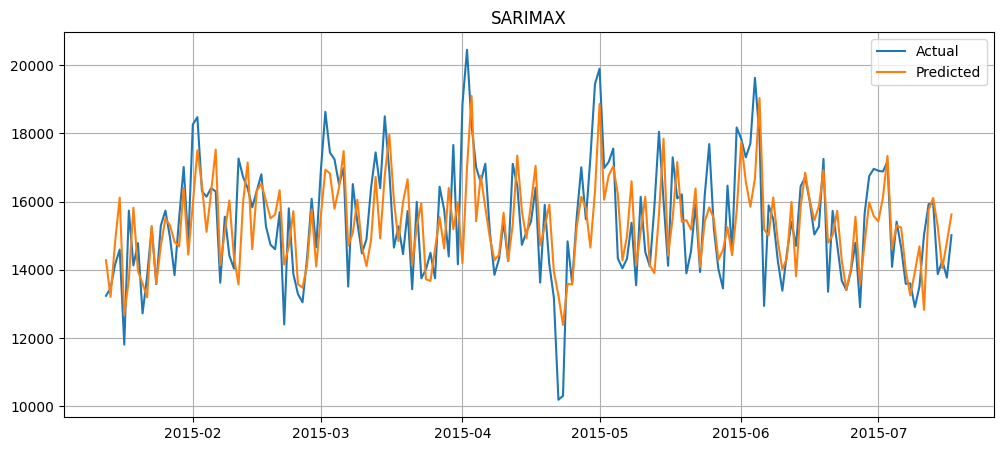

In [ ]:
run_model("SARIMAX",
          SARIMAX(y_train, exog=X_train,
                  order=(5,0,3), seasonal_order=(1,1,1,7)),
          y_train, y_test, X_train, X_test)

In [ ]:
# # =========================================
# # PROPHET MODEL
# # =========================================

# # prepare dataframe (Prophet needs ds, y)
# df_prophet = store_df.reset_index()[['index','Sales','Promo','SchoolHoliday']]
# df_prophet.columns = ['ds','y','Promo','SchoolHoliday']

# # split
# train_p = df_prophet.iloc[:split]
# test_p = df_prophet.iloc[split:]

# # model
# model_p = Prophet(
#     yearly_seasonality=True,
#     weekly_seasonality=True,
#     daily_seasonality=False,
#     changepoint_prior_scale=0.1,
#     seasonality_mode='multiplicative'
# )

# # add regressors
# model_p.add_regressor('Promo')
# model_p.add_regressor('SchoolHoliday')

# # fit
# model_p.fit(train_p)

# # =========================================
# # future dataframe (IMPORTANT)
# # =========================================
# future = model_p.make_future_dataframe(periods=len(test_p))

# future = future.merge(
#     df_prophet[['ds','Promo','SchoolHoliday']],
#     on='ds',
#     how='left'
# )

# future['Promo'] = future['Promo'].fillna(0)
# future['SchoolHoliday'] = future['SchoolHoliday'].fillna(0)

# # predict
# forecast = model_p.predict(future)

# # correct slicing
# preds = forecast['yhat'].iloc[-len(test_p):].values

# # evaluation
# rmse, mae, mape, r2, adj_r2 = evaluate(
#     test_p['y'].values,
#     preds,
#     k=5
# )

# print("\nProphet")
# print("RMSE:", rmse)
# print("MAE:", mae)
# print("MAPE:", mape)
# print("R2:", r2)
# print("Adj R2:", adj_r2)

# results_list.append({
#     "Model": "Prophet",
#     "RMSE": rmse,
#     "MAE": mae,
#     "MAPE": mape,
#     "R2": r2,
#     "Adj_R2": adj_r2,
#     "AIC": None
# })

# models_dict["Prophet"] = model_p

# # plot
# plt.figure(figsize=(12,5))
# plt.plot(test_p['ds'], test_p['y'].values, label="Actual")
# plt.plot(test_p['ds'], preds, label="Predicted")
# plt.title("Prophet")
# plt.legend()
# plt.grid()
# plt.show()


Prophet
RMSE: 1276.455120789703
MAE: 995.1589939090214
MAPE: 6.556883158410651
R2: 0.4242257166215496
Adj R2: 0.4049260199719926


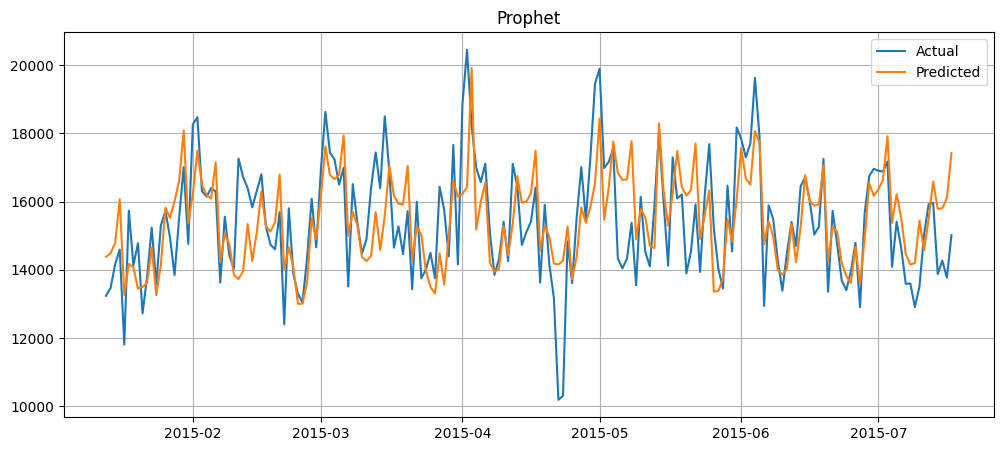

In [ ]:
# =========================================
# PROPHET MODEL (FINAL CORRECTED)
# =========================================

from prophet import Prophet

# -----------------------------------------
# Prepare dataframe
# -----------------------------------------
df_prophet = store_df.reset_index().rename(columns={'index': 'ds'})
df_prophet = df_prophet[['ds','Sales','Promo','SchoolHoliday','StateHoliday','IsWeekend']]
df_prophet = df_prophet.rename(columns={'Sales': 'y'})

# handle zero sales (important improvement)
df_prophet['y'] = df_prophet['y'].replace(0, np.nan).interpolate()

# -----------------------------------------
# Split
# -----------------------------------------
train_p = df_prophet.iloc[:split]
test_p = df_prophet.iloc[split:]

# -----------------------------------------
# Holidays (VERY IMPORTANT for Rossmann)
# -----------------------------------------
from prophet.make_holidays import make_holidays_df

holidays = make_holidays_df(
    year_list=list(range(df_prophet['ds'].dt.year.min(),
                         df_prophet['ds'].dt.year.max()+1)),
    country='DE'
)

# -----------------------------------------
# Model
# -----------------------------------------
model_p = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.01,   # tuned (better than 0.1 usually)
    holidays=holidays
)

# -----------------------------------------
# Add regressors
# -----------------------------------------
model_p.add_regressor('Promo')
model_p.add_regressor('SchoolHoliday')
model_p.add_regressor('StateHoliday')
model_p.add_regressor('IsWeekend')

# optional: extra seasonality
model_p.add_seasonality(
    name='monthly',
    period=30.5,
    fourier_order=5
)

# -----------------------------------------
# Fit
# -----------------------------------------
model_p.fit(train_p)

# -----------------------------------------
# Future dataframe
# -----------------------------------------
future = model_p.make_future_dataframe(periods=len(test_p))

future = future.merge(
    df_prophet[['ds','Promo','SchoolHoliday','StateHoliday','IsWeekend']],
    on='ds',
    how='left'
)

# fill missing regressors safely
for col in ['Promo','SchoolHoliday','StateHoliday','IsWeekend']:
    future[col] = future[col].fillna(0)

# -----------------------------------------
# Predict
# -----------------------------------------
forecast = model_p.predict(future)

# correct slicing
preds = forecast['yhat'].iloc[-len(test_p):].values

# -----------------------------------------
# Evaluation
# -----------------------------------------
rmse, mae, mape, r2, adj_r2 = evaluate(
    test_p['y'].values,
    preds,
    k=6
)

print("\nProphet")
print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)
print("R2:", r2)
print("Adj R2:", adj_r2)

# store results
results_list.append({
    "Model": "Prophet",
    "RMSE": rmse,
    "MAE": mae,
    "MAPE": mape,
    "R2": r2,
    "Adj_R2": adj_r2,
    "AIC": None
})

models_dict["Prophet"] = model_p

# -----------------------------------------
# Plot
# -----------------------------------------
plt.figure(figsize=(12,5))
plt.plot(test_p['ds'], test_p['y'].values, label="Actual")
plt.plot(test_p['ds'], preds, label="Predicted")
plt.title("Prophet")
plt.legend()
plt.grid()
plt.show()

In [ ]:
!pip install tbats

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 12.6 MB/s eta 0:00:00



Fitting TBATS model... (this may take time)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



TBATS
RMSE: 1544.839315806915
MAE: 1200.5751902658226
MAPE: 7.797318501361822
R2: 0.15665011352802993
Adj R2: 0.13322372779269742


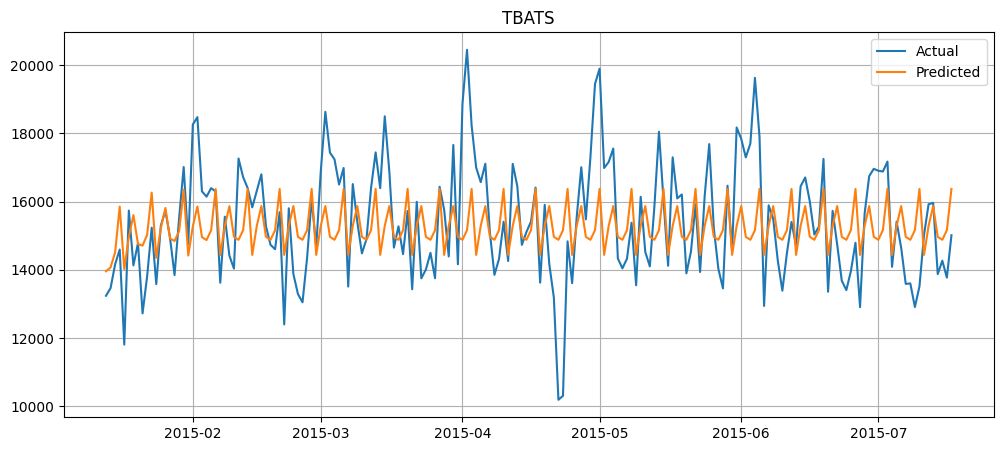

In [ ]:
# =========================================
# TBATS MODEL (CORRECTED FOR YOUR PIPELINE)
# =========================================

from tbats import TBATS

# TBATS only uses univariate series
tbats_series_train = y_train.copy()
tbats_series_test = y_test.copy()

# -----------------------------------------
# Model
# -----------------------------------------
estimator = TBATS(
    seasonal_periods=[7],   # weekly seasonality (VERY important here)
    use_box_cox=False,
    use_trend=True,
    use_damped_trend=True,
    show_warnings=False
)

print("\nFitting TBATS model... (this may take time)")
tbats_model = estimator.fit(tbats_series_train)

# -----------------------------------------
# Forecast
# -----------------------------------------
tbats_pred = tbats_model.forecast(steps=len(tbats_series_test))
tbats_pred = pd.Series(tbats_pred, index=tbats_series_test.index)

# -----------------------------------------
# Evaluation (FIXED: use your evaluate function)
# -----------------------------------------
k_params = 5  # safe approximation (TBATS doesn't expose params cleanly)

rmse, mae, mape, r2, adj_r2 = evaluate(
    tbats_series_test.values,
    tbats_pred.values,
    k=k_params
)

print("\nTBATS")
print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)
print("R2:", r2)
print("Adj R2:", adj_r2)

# -----------------------------------------
# Store results
# -----------------------------------------
results_list.append({
    "Model": "TBATS",
    "RMSE": rmse,
    "MAE": mae,
    "MAPE": mape,
    "R2": r2,
    "Adj_R2": adj_r2,
    "AIC": None
})

models_dict["TBATS"] = tbats_model

# -----------------------------------------
# Plot
# -----------------------------------------
plt.figure(figsize=(12,5))
plt.plot(tbats_series_test, label="Actual")
plt.plot(tbats_pred, label="Predicted")
plt.title("TBATS")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# =========================================
# FINAL RESULTS
# =========================================
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values("RMSE")

print("\nFinal Model Comparison:")
display(results_df)

# =========================================
# SAVE MODELS
# =========================================
os.makedirs("saved_models", exist_ok=True)

for name, model in models_dict.items():
    with open(f"saved_models/{name}.pkl", "wb") as f:
        pickle.dump(model, f)

print("\nAll models saved in 'saved_models/' folder")


Final Model Comparison:


,Model,RMSE,MAE,MAPE,R2,Adj_R2,AIC
6,SARIMAX,1225.928209,953.090808,6.160112,0.468906,0.415165,12620.315223
7,Prophet,1276.455121,995.158994,6.556883,0.424226,0.404926,NaN
5,ARIMAX,1511.814997,1196.030744,7.595383,0.192322,0.141261,12905.454319
8,TBATS,1544.839316,1200.575190,7.797319,0.156650,0.133224,NaN
4,SARIMA,1556.918943,1170.942362,7.558796,0.143410,0.119615,12700.956253
3,ARIMA,1645.990720,1270.137158,8.098033,0.042594,-0.048047,12766.959988
2,ARMA,1697.475641,1307.220528,8.264805,-0.018236,-0.162800,12769.984960
0,AR,1744.852012,1385.492040,8.800980,-0.075866,-0.170796,12594.522568
1,MA,1768.740837,1398.185375,8.876450,-0.105528,-0.210193,12874.364695



All models saved in 'saved_models/' folder


In [ ]:
# =========================================
# FINAL: SARIMAX 30-DAY FORECAST (ROBUST)
# =========================================

sarimax_model = models_dict["SARIMAX"]

# Future dates
future_dates = pd.date_range(
    start=store_df.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq='D'
)

# Exogenous variables
future_exog = pd.DataFrame(index=future_dates)
future_exog["Promo"] = 1
future_exog["SchoolHoliday"] = 0

future_exog["DayOfWeek"] = future_exog.index.dayofweek
future_exog["IsWeekend"] = (future_exog["DayOfWeek"] >= 5).astype(int)

# Lag features
history = store_df["Sales"].tolist()

lag_1, lag_7, lag_14 = [], [], []

for i in range(30):
    l1 = history[-1]
    l7 = history[-7] if len(history) >= 7 else l1
    l14 = history[-14] if len(history) >= 14 else l1

    lag_1.append(l1)
    lag_7.append(l7)
    lag_14.append(l14)

    history.append(l1)

future_exog["lag_1"] = lag_1
future_exog["lag_7"] = lag_7
future_exog["lag_14"] = lag_14

# Clean
future_exog = future_exog.fillna(0)
future_exog = future_exog.replace([np.inf, -np.inf], 0)

future_exog = future_exog[X_train.columns]

# Forecast
start = len(y_train)
end = start + 29

forecast_obj = sarimax_model.get_prediction(
    start=start,
    end=end,
    exog=future_exog
)

sarimax_forecast = forecast_obj.predicted_mean
sarimax_forecast.index = future_dates


Generating final test + future comparison plot...


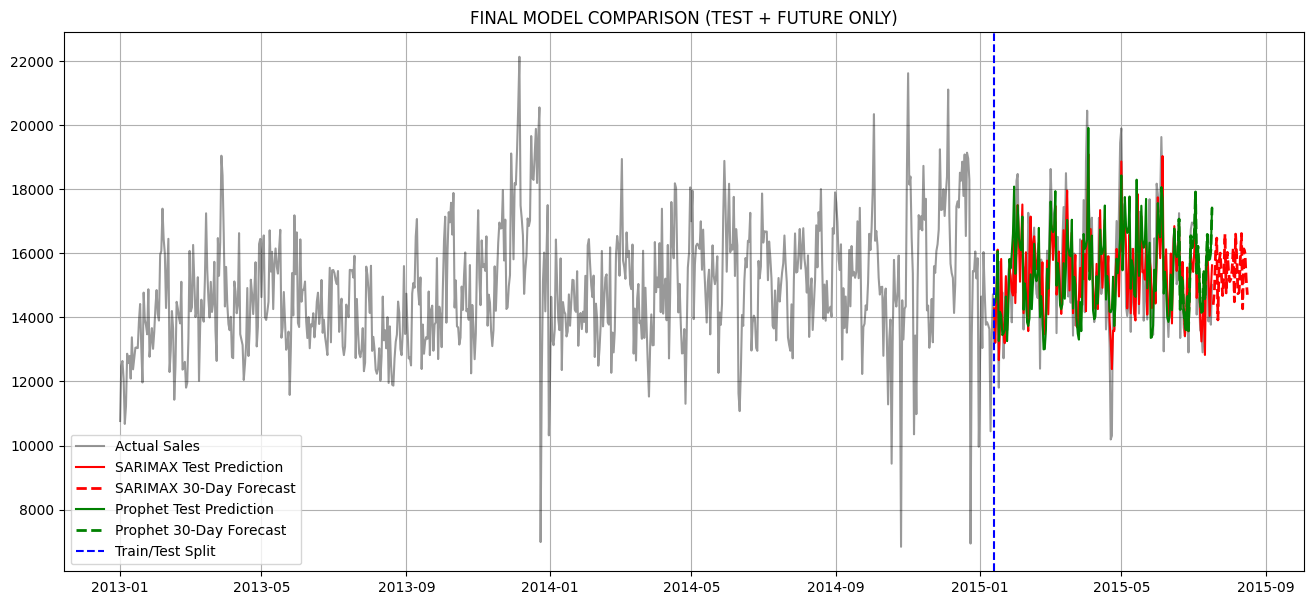

In [ ]:
# =========================================
# FINAL CLEAN TIMELINE: TEST + FUTURE ONLY
# SARIMAX vs PROPHET
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("\nGenerating final test + future comparison plot...")

# =========================================
# 1. ACTUAL DATA
# =========================================
actual = store_df["Sales"]

train_size = len(y_train)

# =========================================
# 2. SARIMAX TEST PREDICTIONS
# =========================================
sarimax_model = models_dict["SARIMAX"]

sarimax_test = sarimax_model.predict(
    start=train_size,
    end=len(store_df) - 1,
    exog=X_test
)

sarimax_test.index = store_df.index[train_size:]

# =========================================
# 3. SARIMAX FUTURE (30 DAYS)
# already computed: sarimax_forecast
# =========================================

future_dates = pd.date_range(
    start=store_df.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq='D'
)

sarimax_future = sarimax_forecast
sarimax_future.index = future_dates

# =========================================
# 4. PROPHET TEST + FUTURE ONLY
# =========================================

prophet_test = forecast[['ds', 'yhat']].iloc[train_size:train_size + len(y_test)].copy()
prophet_test = prophet_test.set_index('ds')

future_30 = model_p.make_future_dataframe(periods=len(test_p) + 30)
future_30 = future_30.merge(
    df_prophet[['ds','Promo','SchoolHoliday','StateHoliday','IsWeekend']],
    on='ds',
    how='left'
)

for col in ['Promo','SchoolHoliday','StateHoliday','IsWeekend']:
    future_30[col] = future_30[col].fillna(0)

forecast_full = model_p.predict(future_30)
forecast_full = forecast_full.set_index('ds')
# TEST
prophet_test = forecast_full.iloc[train_size:train_size + len(y_test)]

# FUTURE (real future now)
prophet_future = forecast_full.iloc[train_size + len(y_test):]

prophet_future = forecast[['ds', 'yhat']].tail(30).set_index('ds')

# =========================================
# 5. PLOT (ONLY TEST + FUTURE)
# =========================================

plt.figure(figsize=(16,7))

# Actual full line (reference only)
plt.plot(actual.index, actual.values,
         color="black", alpha=0.4, label="Actual Sales")

# -------------------------
# SARIMAX TEST
# -------------------------
plt.plot(sarimax_test.index, sarimax_test.values,
         color="red", label="SARIMAX Test Prediction")

# # SARIMAX FUTURE
plt.plot(sarimax_future.index, sarimax_future.values,
         color="red", linestyle="--", linewidth=2,
         label="SARIMAX 30-Day Forecast")

# -------------------------
# PROPHET TEST
# -------------------------
plt.plot(prophet_test.index, prophet_test['yhat'],
         color="green", label="Prophet Test Prediction")

# # PROPHET FUTURE
plt.plot(prophet_future.index, prophet_future['yhat'],
         color="green", linestyle="--", linewidth=2,
         label="Prophet 30-Day Forecast")

# -------------------------
# SPLIT LINE
# -------------------------
plt.axvline(x=store_df.index[train_size],
            color='blue', linestyle='--', label="Train/Test Split")

# =========================================
# FINAL STYLE
# =========================================
plt.title("FINAL MODEL COMPARISON (TEST + FUTURE ONLY)")
plt.legend()
plt.grid()
plt.show()